# Notebook 07 — Supervised 2D Encoder (Phase 1 of Extension Plan)
**Project:** ENSO-BSISO Self-Supervised Learning  
**Author:** Jiayi (jh9141@nyu.edu)

This notebook is **identical to notebook 04** in every way *except*:
- Encoder embedding dim: 64 → **2**
- Hardcoded to MJJAS Lee preprocessing (no APPROACH config)
- Outputs go to `results/lee_2d/` (do not overwrite the 64D baseline)

**Phase 1 goal** (from `results/extension_2d_plan.md`): test whether squeezing the encoder to 2D preserves the structure visible in the 64D + t-SNE result.

With L2 normalization, 2D embeddings lie on the **unit circle in R²** — a natural geometry for a phase variable. Each embedding is fully described by a single angle θ ∈ [-π, π].

**Inputs (from Google Drive):**
- `data/processed/X_MJJAS_lee.npy` — shape `(6579, 3, 31, 51)`
- `data/processed/labels_aligned_mjjas_lee.csv`

**Outputs (saved to Drive):**
- `checkpoints/encoder_2d_lee_final.pth`, `checkpoints/encoder_2d_lee_epoch_N.pth` (every 10 epochs)
- `checkpoints/training_history_2d_lee.json`
- `results/lee_2d/training_curves.png`
- `results/lee_2d/embeddings.npy`
- `results/lee_2d/embedding_2d_overview.png`, `embedding_2d_by_phase.png`
- `results/lee_2d/linear_probe_results.json`
- `results/lee_2d/enso_displacement.png`
- `results/lee_2d/phase1_comparison.md`

**Baselines to compare against (64D Lee MJJAS, year-based split):**
- BSISO phase val acc: **67.7%** (5-fold CV: 68.6% ± 1.0%)
- ENSO displacement z-score: **3.83**

**Decision criterion:** if 2D probe ≥ ~62% and z-score ≥ ~3.0 → BSISO is ≤2D in this representation, greenlight Phase 2. Otherwise run Phase 4 dimension sweep first.

**Runtime:** ~30 min on Colab T4.

---
## Before Running
1. Verify `data/processed/X_MJJAS_lee.npy` and `labels_aligned_mjjas_lee.csv` exist (from notebook 03 / 06).
2. Set runtime to GPU: **Runtime → Change runtime type → T4 GPU**.

## Cell 1 — Mount Drive + Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import matplotlib.pyplot as plt

# ── Phase 1 config (extension_2d_plan.md) ────────────────────────────────────
EMBEDDING_DIM = 2          # ← the only architectural change vs notebook 04
APPROACH      = 'lee'      # MJJAS Lee preprocessing (existing pipeline)
RUN_TAG       = '2d_lee'   # used in all output filenames
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR    = '/content/drive/MyDrive/BSISO_SSL_Project'
PROCESSED_DIR  = f'{PROJECT_DIR}/data/processed'
CHECKPOINT_DIR = f'{PROJECT_DIR}/checkpoints'
RESULTS_DIR    = f'{PROJECT_DIR}/results/lee_2d'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

X_FILE      = 'X_MJJAS_lee.npy'
LABELS_FILE = 'labels_aligned_mjjas_lee.csv'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device:        {device}')
print(f'Embedding dim: {EMBEDDING_DIM}')
print(f'Data:          {X_FILE}')
print(f'Labels:        {LABELS_FILE}')
print(f'Checkpoints:   encoder_{RUN_TAG}_final.pth')
print(f'Results:       results/lee_2d/')

Mounted at /content/drive
Device:        cuda
Embedding dim: 2
Data:          X_MJJAS_lee.npy
Labels:        labels_aligned_mjjas_lee.csv
Checkpoints:   encoder_2d_lee_final.pth
Results:       results/lee_2d/


## Cell 2 — Load Data + Year-Based Train/Val Split + Phase-ENSO Index

**Year-based split** prevents same-year ENSO leakage: every 5th year held out for val. Regenerated deterministically here (do not rely on cached `train_indices.npy`, which other notebooks may overwrite).

In [2]:
X      = np.load(f'{PROCESSED_DIR}/{X_FILE}')
labels = pd.read_csv(f'{PROCESSED_DIR}/{LABELS_FILE}', parse_dates=['date'])

print(f'X shape:  {X.shape}  (N, channels, lat, lon)')
print(f'Labels:   {len(labels)} rows')
print(f'\nBSISO phase distribution:')
print(labels['bsiso_phase'].value_counts().sort_index())
print(f'\nENSO distribution:')
print(labels['enso_category'].value_counts())

# --- Year-based train/val split (~80/20) ---
# Hold out every 5th year as validation (no same-year leakage).
# Regenerate deterministically — do NOT rely on cached train_indices.npy.
all_years = sorted(labels['date'].dt.year.unique())
val_years = all_years[::5]
train_years = [y for y in all_years if y not in val_years]

year_col  = labels['date'].dt.year
train_idx = labels.index[year_col.isin(train_years)].values
val_idx   = labels.index[year_col.isin(val_years)].values

# Save with run-tagged filenames so we don't clobber notebook 04's split files.
np.save(f'{PROCESSED_DIR}/train_indices_{RUN_TAG}.npy', train_idx)
np.save(f'{PROCESSED_DIR}/val_indices_{RUN_TAG}.npy',   val_idx)

print(f'\n--- Year-based split ---')
print(f'Val years ({len(val_years)}):   {val_years}')
print(f'Train years ({len(train_years)}): {train_years}')
print(f'Train: {len(train_idx)} samples ({100*len(train_idx)/len(labels):.1f}%)')
print(f'Val:   {len(val_idx)} samples ({100*len(val_idx)/len(labels):.1f}%)')

val_enso = labels.loc[val_idx, 'enso_category'].value_counts()
print(f'\nENSO distribution in val set:')
print(val_enso)
if val_enso.get('El Nino', 0) == 0 or val_enso.get('La Nina', 0) == 0:
    print('WARNING: val set missing an ENSO category — consider adjusting val_years')

# --- Build phase-ENSO index (active BSISO only: amplitude > 1.0) ---
phase_enso_index = defaultdict(list)
for idx in train_idx:
    row = labels.loc[idx]
    if row['bsiso_amplitude'] > 1.0:
        key = (row['bsiso_phase'], row['enso_category'])
        phase_enso_index[key].append(idx)

active_total = sum(len(v) for v in phase_enso_index.values())
print(f'\nActive BSISO days in TRAIN (amplitude > 1.0): {active_total} / {len(train_idx)}')
print('\nSample counts per (phase, ENSO) in TRAIN:')
for key in sorted(phase_enso_index.keys()):
    n = len(phase_enso_index[key])
    flag = '  << sparse' if n < 20 else ''
    print(f'  {key}: {n}{flag}')

X shape:  (6579, 3, 31, 51)  (N, channels, lat, lon)
Labels:   6579 rows

BSISO phase distribution:
bsiso_phase
1    888
2    832
3    953
4    671
5    785
6    831
7    704
8    915
Name: count, dtype: int64

ENSO distribution:
enso_category
Neutral    3825
La Nina    1683
El Nino    1071
Name: count, dtype: int64

--- Year-based split ---
Val years (9):   [np.int32(1981), np.int32(1986), np.int32(1991), np.int32(1996), np.int32(2001), np.int32(2006), np.int32(2011), np.int32(2016), np.int32(2021)]
Train years (34): [np.int32(1982), np.int32(1983), np.int32(1984), np.int32(1985), np.int32(1987), np.int32(1988), np.int32(1989), np.int32(1990), np.int32(1992), np.int32(1993), np.int32(1994), np.int32(1995), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2017), np.int32(20

## Cell 3 — PairSampler (identical to notebook 04)

In [3]:
class PairSampler:
    def __init__(self, labels_df, phase_enso_index):
        self.labels = labels_df
        self.index  = phase_enso_index
        self.enso_categories = labels_df['enso_category'].unique().tolist()

    def sample_positive_pair(self):
        """Same phase + same ENSO, different years."""
        key = self._random_category()
        indices = self.index[key]
        if len(indices) < 2:
            return self.sample_easy_negative_pair()
        idx_A, idx_B = np.random.choice(indices, size=2, replace=False)
        year_A = self.labels.loc[idx_A, 'date'].year
        other = [i for i in indices if self.labels.loc[i, 'date'].year != year_A]
        if other:
            idx_B = np.random.choice(other)
        return idx_A, idx_B, 'positive'

    def sample_hard_negative_pair(self):
        """Same phase, different ENSO."""
        if len(self.enso_categories) < 2:
            return self.sample_easy_negative_pair()
        phase = np.random.choice(range(1, 9))
        enso_A, enso_B = np.random.choice(self.enso_categories, size=2, replace=False)
        key_A, key_B = (phase, enso_A), (phase, enso_B)
        if not self.index[key_A] or not self.index[key_B]:
            return self.sample_positive_pair()
        idx_A = np.random.choice(self.index[key_A])
        idx_B = np.random.choice(self.index[key_B])
        return idx_A, idx_B, 'hard_negative'

    def sample_easy_negative_pair(self):
        """Different phases."""
        phase_A, phase_B = np.random.choice(range(1, 9), size=2, replace=False)
        enso_A = np.random.choice(self.enso_categories)
        enso_B = np.random.choice(self.enso_categories)
        key_A, key_B = (phase_A, enso_A), (phase_B, enso_B)
        idx_A = (np.random.choice(self.index[key_A]) if self.index[key_A]
                 else self.labels[self.labels['bsiso_phase'] == phase_A].sample(1).index[0])
        idx_B = (np.random.choice(self.index[key_B]) if self.index[key_B]
                 else self.labels[self.labels['bsiso_phase'] == phase_B].sample(1).index[0])
        return idx_A, idx_B, 'easy_negative'

    def sample_batch(self, batch_size=64, positive_ratio=0.3, hard_negative_ratio=0.2):
        n_pos      = int(batch_size * positive_ratio)
        n_hard_neg = int(batch_size * hard_negative_ratio)
        n_easy_neg = batch_size - n_pos - n_hard_neg
        pairs = ([self.sample_positive_pair()      for _ in range(n_pos)] +
                 [self.sample_hard_negative_pair() for _ in range(n_hard_neg)] +
                 [self.sample_easy_negative_pair() for _ in range(n_easy_neg)])
        return pairs

    def _random_category(self):
        valid = [k for k in self.index if len(self.index[k]) > 0]
        return valid[np.random.randint(len(valid))]

# Quick test
sampler = PairSampler(labels, phase_enso_index)
batch   = sampler.sample_batch(batch_size=64)
types   = [p[2] for p in batch]
print(f'Batch composition: positive={types.count("positive")},  '
      f'hard_neg={types.count("hard_negative")},  easy_neg={types.count("easy_negative")}')

Batch composition: positive=19,  hard_neg=12,  easy_neg=33


## Cell 4 — BSISOPairDataset + DataLoader (identical to notebook 04)

In [4]:
class BSISOPairDataset(Dataset):
    def __init__(self, X_data, labels_df, phase_enso_index,
                 mode='train', train_indices=None):
        self.X       = X_data
        self.labels  = labels_df
        self.sampler = PairSampler(labels_df, phase_enso_index)
        self.mode    = mode
        self.train_indices = (train_indices if train_indices is not None
                              else np.arange(len(X_data)))
        if mode == 'val':
            self.val_pairs = self._create_val_pairs()

    def _create_val_pairs(self):
        pairs = []
        val_labels = self.labels.loc[self.train_indices]
        for phase in range(1, 9):
            for enso in self.sampler.enso_categories:
                group = val_labels[
                    (val_labels['bsiso_phase'] == phase) &
                    (val_labels['enso_category'] == enso)
                ].index.tolist()
                for i in range(len(group)):
                    for j in range(i + 1, len(group)):
                        pairs.append((group[i], group[j], 'positive'))
        return pairs[:1000]

    def __len__(self):
        return (len(self.train_indices) if self.mode == 'train'
                else len(self.val_pairs))

    def __getitem__(self, idx):
        if self.mode == 'train':
            r = np.random.rand()
            if r < 0.30:
                idx_A, idx_B, _ = self.sampler.sample_positive_pair()
            elif r < 0.50:
                idx_A, idx_B, _ = self.sampler.sample_hard_negative_pair()
            else:
                idx_A, idx_B, _ = self.sampler.sample_easy_negative_pair()
        else:
            idx_A, idx_B, _ = self.val_pairs[idx]
        field_A = torch.from_numpy(self.X[idx_A]).float()
        field_B = torch.from_numpy(self.X[idx_B]).float()
        return field_A, field_B


train_dataset = BSISOPairDataset(X, labels, phase_enso_index,
                                  mode='train', train_indices=train_idx)
val_dataset   = BSISOPairDataset(X, labels, phase_enso_index,
                                  mode='val',   train_indices=val_idx)

train_loader = DataLoader(train_dataset, batch_size=64,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train dataset: {len(train_dataset)} items  →  {len(train_loader)} batches/epoch')
print(f'Val dataset:   {len(val_dataset)} pairs   →  {len(val_loader)} batches')

batch_A, batch_B = next(iter(train_loader))
print(f'\nBatch A shape: {batch_A.shape}  (should be [64, 3, 31, 51])')
print(f'Batch B shape: {batch_B.shape}')

Train dataset: 5202 items  →  82 batches/epoch
Val dataset:   1000 pairs   →  16 batches

Batch A shape: torch.Size([64, 3, 31, 51])  (should be [64, 3, 31, 51])
Batch B shape: torch.Size([64, 3, 31, 51])


## Cell 5 — CNN Encoder (embedding_dim = 2)

Only change vs notebook 04: final FC layer is `nn.Linear(128, 2)` instead of `nn.Linear(128, 64)`. Everything else (3 conv blocks, BN, global avg pool, L2 normalization) is identical.

**Geometric note:** with `EMBEDDING_DIM=2` and L2 normalization, every embedding lies on the unit circle in R² — a single angle θ describes it completely. This is the natural geometry for a phase variable like BSISO.

In [5]:
class CNNEncoder(nn.Module):
    def __init__(self, embedding_dim=2):     # ← default changed from 64 → 2
        super().__init__()
        # Block 1: 3 → 32 channels, MaxPool /2
        self.conv1 = nn.Conv2d(3,  32, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        # Block 2: 32 → 64 channels, MaxPool /2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        # Block 3: 64 → 128 channels (no pooling)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(128)
        # Global pooling + FC
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc          = nn.Linear(128, embedding_dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).view(x.size(0), -1)
        z = self.fc(x)
        z = F.normalize(z, p=2, dim=1)   # → unit circle in R^2 when dim=2
        return z

# Test
encoder = CNNEncoder(embedding_dim=EMBEDDING_DIM)
total_params = sum(p.numel() for p in encoder.parameters())
print(f'Total parameters: {total_params:,}')
print(f'(64D version had ~101,728 params — 2D shrinks the FC layer from 128*64+64 to 128*2+2)')

dummy = torch.randn(4, 3, 31, 51)
out   = encoder(dummy)
print(f'\nInput:  {dummy.shape}')
print(f'Output: {out.shape}   (should be [4, {EMBEDDING_DIM}])')
print(f'Norms:  {out.norm(dim=1)}  (should all be 1.0)')

Total parameters: 93,730
(64D version had ~101,728 params — 2D shrinks the FC layer from 128*64+64 to 128*2+2)

Input:  torch.Size([4, 3, 31, 51])
Output: torch.Size([4, 2])   (should be [4, 2])
Norms:  tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<LinalgVectorNormBackward0>)  (should all be 1.0)


## Cell 6 — InfoNCE Loss (identical)

NT-Xent. With L2-normalized 2D embeddings, similarity is cosine of the angle between unit vectors on the circle. Random embeddings on S¹ in R² have a non-uniform similarity distribution (some pairs will be near-aligned by chance), so the random-embedding loss may be slightly different from log(B), but log(B) ≈ 4.16 is still a useful order-of-magnitude check.

In [6]:
def InfoNCE_loss(z_A, z_B, temperature=0.07):
    sim_matrix = torch.matmul(z_A, z_B.T) / temperature
    labels_ = torch.arange(z_A.size(0), device=z_A.device)
    return F.cross_entropy(sim_matrix, labels_)

z_A = F.normalize(torch.randn(64, EMBEDDING_DIM), p=2, dim=1)
z_B = F.normalize(torch.randn(64, EMBEDDING_DIM), p=2, dim=1)
loss = InfoNCE_loss(z_A, z_B, temperature=0.07)
print(f'Loss (random {EMBEDDING_DIM}D embeddings): {loss.item():.4f}')
print(f'Reference: log(64) = {np.log(64):.4f}')

Loss (random 2D embeddings): 15.2827
Reference: log(64) = 4.1589


## Cell 7 — CPU Smoke Test (2 epochs, 100 samples)

Verify the full pipeline runs end-to-end. Loss should drop from ~4.5 to ~3.5 over 2 epochs.

In [7]:
X_test      = X[:100]
labels_test = labels.iloc[:100].copy().reset_index(drop=True)

pei_test = defaultdict(list)
for idx, row in labels_test.iterrows():
    if row['bsiso_amplitude'] > 1.0:
        pei_test[(row['bsiso_phase'], row['enso_category'])].append(idx)

test_dataset = BSISOPairDataset(X_test, labels_test, pei_test, mode='train')
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=True)

enc_test  = CNNEncoder(embedding_dim=EMBEDDING_DIM)   # CPU
opt_test  = optim.Adam(enc_test.parameters(), lr=1e-3)

enc_test.train()
for epoch in range(2):
    epoch_loss = 0.0
    for batch_idx, (fA, fB) in enumerate(test_loader):
        z_A = enc_test(fA)
        z_B = enc_test(fB)
        loss = InfoNCE_loss(z_A, z_B)
        opt_test.zero_grad()
        loss.backward()
        opt_test.step()
        epoch_loss += loss.item()
        if batch_idx % 5 == 0:
            print(f'  Epoch {epoch}  batch {batch_idx}  loss={loss.item():.4f}')
    print(f'Epoch {epoch} avg loss: {epoch_loss/len(test_loader):.4f}\n')

print('CPU smoke test passed!')

  Epoch 0  batch 0  loss=2.1804
  Epoch 0  batch 5  loss=2.0881
  Epoch 0  batch 10  loss=2.0779
Epoch 0 avg loss: 2.0386

  Epoch 1  batch 0  loss=2.0830
  Epoch 1  batch 5  loss=2.0916
  Epoch 1  batch 10  loss=2.0650
Epoch 1 avg loss: 2.0342

CPU smoke test passed!


## Cell 8 — Initialize Model + Optimizer for Full Training

In [8]:
EPOCHS      = 50
TEMPERATURE = 0.07
BATCH_SIZE  = 64
LR          = 1e-3

encoder   = CNNEncoder(embedding_dim=EMBEDDING_DIM).to(device)
optimizer = optim.Adam(encoder.parameters(), lr=LR, weight_decay=0)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

total_params = sum(p.numel() for p in encoder.parameters())
print(f'Model on: {device}')
print(f'Parameters: {total_params:,}')
print(f'\nTraining config:')
print(f'  Epochs:        {EPOCHS}')
print(f'  Batch size:    {BATCH_SIZE}')
print(f'  Temperature:   {TEMPERATURE}')
print(f'  LR:            {LR}  (cosine decay to 1e-5)')
print(f'  Embedding dim: {EMBEDDING_DIM}')
print(f'  Train batches/epoch: {len(train_loader)}')

Model on: cuda
Parameters: 93,730

Training config:
  Epochs:        50
  Batch size:    64
  Temperature:   0.07
  LR:            0.001  (cosine decay to 1e-5)
  Embedding dim: 2
  Train batches/epoch: 82


## Cell 9 — Full Training Loop

**Expected:** ~30 min on T4 (same as 64D, encoder size barely changed). Checkpoints every 10 epochs.

In [9]:
from tqdm.notebook import tqdm

history = {'train_loss': [], 'val_loss': [], 'epoch_time': []}

for epoch in range(EPOCHS):
    t0 = time.time()

    # ---- TRAIN ----
    encoder.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False)
    for field_A, field_B in pbar:
        field_A = field_A.to(device, non_blocking=True)
        field_B = field_B.to(device, non_blocking=True)
        z_A = encoder(field_A)
        z_B = encoder(field_B)
        loss = InfoNCE_loss(z_A, z_B, temperature=TEMPERATURE)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    train_loss /= len(train_loader)

    # ---- VALIDATE ----
    encoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for field_A, field_B in val_loader:
            field_A = field_A.to(device, non_blocking=True)
            field_B = field_B.to(device, non_blocking=True)
            z_A = encoder(field_A)
            z_B = encoder(field_B)
            val_loss += InfoNCE_loss(z_A, z_B, temperature=TEMPERATURE).item()
    val_loss /= len(val_loader)

    scheduler.step()

    epoch_time = time.time() - t0
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['epoch_time'].append(epoch_time)

    print(f'Epoch {epoch+1:2d}/{EPOCHS}  '
          f'train={train_loss:.4f}  val={val_loss:.4f}  '
          f'lr={scheduler.get_last_lr()[0]:.2e}  '
          f'time={epoch_time:.1f}s')

    if (epoch + 1) % 10 == 0:
        ckpt_path = f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_epoch_{epoch+1}.pth'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': encoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, ckpt_path)
        print(f'  -> Checkpoint saved: {ckpt_path}')

torch.save(encoder.state_dict(), f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_final.pth')
with open(f'{CHECKPOINT_DIR}/training_history_{RUN_TAG}.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\nTraining complete!  [{RUN_TAG}]')
print(f'Total time: {sum(history["epoch_time"])/60:.1f} minutes')
print(f'Best val loss: {min(history["val_loss"]):.4f}  (epoch {history["val_loss"].index(min(history["val_loss"]))+1})')
print(f'Saved: encoder_{RUN_TAG}_final.pth  |  training_history_{RUN_TAG}.json')

Epoch 1/50 [Train]:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch  1/50  train=4.1178  val=4.1805  lr=9.99e-04  time=5.2s


Epoch 2/50 [Train]:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch  2/50  train=4.0947  val=4.1370  lr=9.96e-04  time=3.9s


Epoch 3/50 [Train]:   0%|          | 0/82 [00:00<?, ?it/s]

...

Epoch 48/50  train=4.0696  val=4.1331  lr=1.39e-05  time=5.1s


Epoch 49/50 [Train]:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 49/50  train=4.0639  val=4.1338  lr=1.10e-05  time=4.6s


Epoch 50/50 [Train]:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 50/50  train=4.0623  val=4.1341  lr=1.00e-05  time=3.9s
  -> Checkpoint saved: /content/drive/MyDrive/BSISO_SSL_Project/checkpoints/encoder_2d_lee_epoch_50.pth

Training complete!  [2d_lee]
Total time: 3.7 minutes
Best val loss: 4.1312  (epoch 10)
Saved: encoder_2d_lee_final.pth  |  training_history_2d_lee.json


## Cell 10 — Training Curves

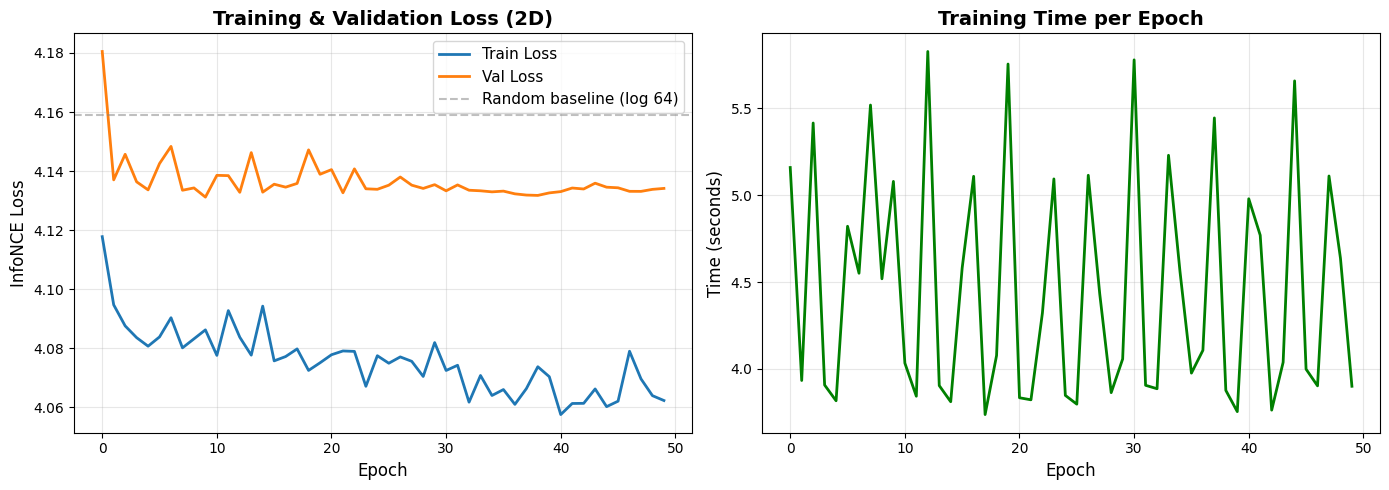

Avg epoch time: 4.5s
Total time:     3.7 min
Plot saved:     /content/drive/MyDrive/BSISO_SSL_Project/results/lee_2d/training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   linewidth=2)
axes[0].axhline(y=np.log(64), color='gray', linestyle='--', alpha=0.5, label='Random baseline (log 64)')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('InfoNCE Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss (2D)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch_time'], color='green', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Time (seconds)', fontsize=12)
axes[1].set_title('Training Time per Epoch', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plot_path = f'{RESULTS_DIR}/training_curves.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Avg epoch time: {np.mean(history["epoch_time"]):.1f}s')
print(f'Total time:     {sum(history["epoch_time"])/60:.1f} min')
print(f'Plot saved:     {plot_path}')

## Cell 11 — Post-Training Health Checks

In [11]:
from scipy.spatial.distance import pdist

print('=' * 55)
print('POST-TRAINING HEALTH CHECKS')
print('=' * 55)

loss_drop = (history['train_loss'][0] - history['train_loss'][-1]) / history['train_loss'][0]
if history['train_loss'][-1] < history['train_loss'][0] * 0.9:
    print(f'  Loss decreased {loss_drop*100:.0f}%  ({history["train_loss"][0]:.4f} -> {history["train_loss"][-1]:.4f})')
else:
    print('  WARNING: Loss did not decrease significantly!')

if history['val_loss'][-1] > history['train_loss'][-1] * 1.5:
    print('  WARNING: Possible overfitting (val >> train loss)')
else:
    print(f'  Train/val gap OK  (train={history["train_loss"][-1]:.4f}, val={history["val_loss"][-1]:.4f})')

encoder.eval()
with torch.no_grad():
    sample = torch.from_numpy(X[:200]).float().to(device)
    embeddings_sample = encoder(sample).cpu().numpy()

distances = pdist(embeddings_sample, metric='cosine')
print(f'\nEmbedding diversity (cosine distance on 200 samples):')
print(f'  Mean pairwise distance: {distances.mean():.4f}')
print(f'  Std  pairwise distance: {distances.std():.4f}')
if distances.mean() < 0.1:
    print('  WARNING: Embeddings may have collapsed (all similar)!')
else:
    print('  Embeddings are diverse')

# 2D-specific: check angular spread on the circle
angles = np.arctan2(embeddings_sample[:, 1], embeddings_sample[:, 0])
print(f'\nAngular spread (rad): range {angles.min():.2f} to {angles.max():.2f}')
print(f'  Should cover most of [-π, π] = [-3.14, 3.14] if phases are well-separated.')

print()
print('Files on Google Drive:')
for fname in [f'encoder_{RUN_TAG}_final.pth', f'training_history_{RUN_TAG}.json',
              f'encoder_{RUN_TAG}_epoch_10.pth', f'encoder_{RUN_TAG}_epoch_20.pth',
              f'encoder_{RUN_TAG}_epoch_30.pth', f'encoder_{RUN_TAG}_epoch_40.pth',
              f'encoder_{RUN_TAG}_epoch_50.pth']:
    path = f'{CHECKPOINT_DIR}/{fname}'
    if os.path.exists(path):
        mb = os.path.getsize(path) / 1e6
        print(f'  {fname}  ({mb:.2f} MB)')
print('=' * 55)

POST-TRAINING HEALTH CHECKS
  Train/val gap OK  (train=4.0623, val=4.1341)

Embedding diversity (cosine distance on 200 samples):
  Mean pairwise distance: 0.0255
  Std  pairwise distance: 0.0308

Angular spread (rad): range -2.04 to -1.43
  Should cover most of [-π, π] = [-3.14, 3.14] if phases are well-separated.

Files on Google Drive:
  encoder_2d_lee_final.pth  (0.38 MB)
  training_history_2d_lee.json  (0.00 MB)
  encoder_2d_lee_epoch_10.pth  (1.14 MB)
  encoder_2d_lee_epoch_20.pth  (1.14 MB)
  encoder_2d_lee_epoch_30.pth  (1.14 MB)
  encoder_2d_lee_epoch_40.pth  (1.14 MB)
  encoder_2d_lee_epoch_50.pth  (1.14 MB)


---
# Phase 1 Diagnostics

**Goal:** Compare 2D model against the 64D Lee MJJAS baseline (`results/lee/`) on:
- BSISO phase linear probe (target ≥ ~62%, baseline 67.7%)
- ENSO **balanced**-accuracy probe (new — addresses class-imbalance issue from 64D run)
- ENSO displacement z-score (target ≥ ~3.0, baseline 3.83)
- 2D scatter (no t-SNE needed — embeddings are already 2D, lying on the unit circle)

## Cell 12 — Extract 2D Embeddings for All Frames

In [12]:
encoder.eval()
embeddings_2d = np.zeros((len(X), EMBEDDING_DIM), dtype=np.float32)
BATCH = 128
with torch.no_grad():
    for start in range(0, len(X), BATCH):
        end   = min(start + BATCH, len(X))
        batch = torch.from_numpy(X[start:end]).float().to(device)
        embeddings_2d[start:end] = encoder(batch).cpu().numpy()

emb_path = f'{RESULTS_DIR}/embeddings.npy'
np.save(emb_path, embeddings_2d)
print(f'Embeddings shape: {embeddings_2d.shape}')
print(f'Norms (first 5): {np.linalg.norm(embeddings_2d[:5], axis=1)}  (should all be ~1.0)')
print(f'Saved: results/lee_2d/embeddings.npy')

Embeddings shape: (6579, 2)
Norms (first 5): [1.        0.9999999 1.        1.        1.       ]  (should all be ~1.0)
Saved: results/lee_2d/embeddings.npy


## Cell 13 — 2D Scatter (Val Set) Colored by Phase + ENSO

Direct visualization of the embedding space — no t-SNE needed since the embeddings are already 2D. With L2 normalization, all points lie on the unit circle (drawn as a dashed reference line).

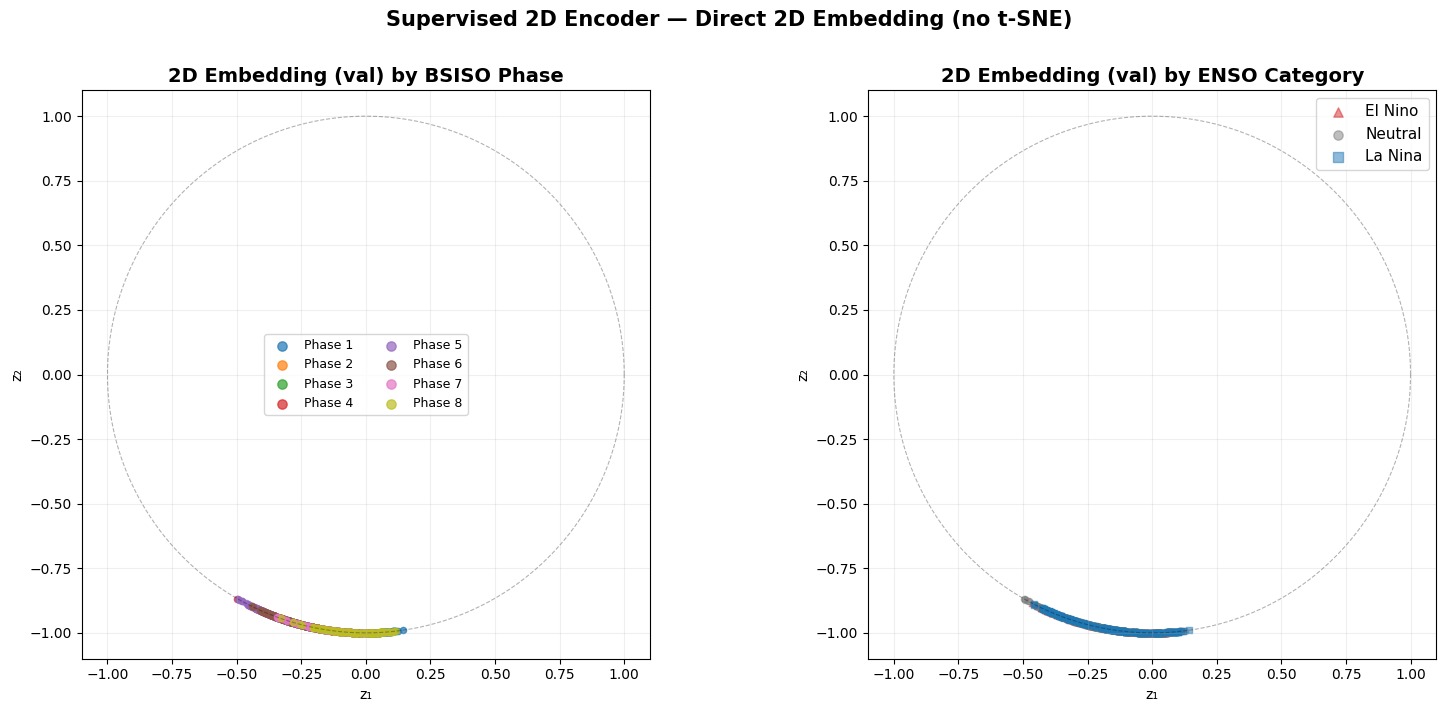

Saved: results/lee_2d/embedding_2d_overview.png


In [13]:
Z_val_2d = embeddings_2d[val_idx]
labels_val = labels.loc[val_idx]

phase_colors = plt.cm.tab10(np.linspace(0, 0.8, 8))
enso_palette = {'El Nino': '#d62728', 'Neutral': '#7f7f7f', 'La Nina': '#1f77b4'}
enso_marker  = {'El Nino': '^',       'Neutral': 'o',        'La Nina': 's'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
theta = np.linspace(0, 2*np.pi, 200)

# Left: by BSISO phase
ax = axes[0]
for phase in range(1, 9):
    mask = labels_val['bsiso_phase'] == phase
    ax.scatter(Z_val_2d[mask, 0], Z_val_2d[mask, 1],
               c=[phase_colors[phase - 1]], s=20, alpha=0.7, label=f'Phase {phase}')
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, linewidth=0.8)
ax.set_title('2D Embedding (val) by BSISO Phase', fontsize=14, fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9, markerscale=1.5, ncol=2, loc='best')
ax.grid(alpha=0.2)

# Right: by ENSO
ax = axes[1]
for cat in ['El Nino', 'Neutral', 'La Nina']:
    mask = labels_val['enso_category'] == cat
    ax.scatter(Z_val_2d[mask, 0], Z_val_2d[mask, 1],
               c=enso_palette[cat], marker=enso_marker[cat],
               s=20, alpha=0.5, label=cat)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, linewidth=0.8)
ax.set_title('2D Embedding (val) by ENSO Category', fontsize=14, fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=11, markerscale=1.5, loc='best')
ax.grid(alpha=0.2)

plt.suptitle('Supervised 2D Encoder — Direct 2D Embedding (no t-SNE)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/embedding_2d_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/lee_2d/embedding_2d_overview.png')

## Cell 14 — 2D Scatter Per-Phase, Colored by ENSO

8-panel: one per BSISO phase. Within each panel, ENSO subgroups should cluster at different angular positions if the model captures within-phase ENSO modulation.

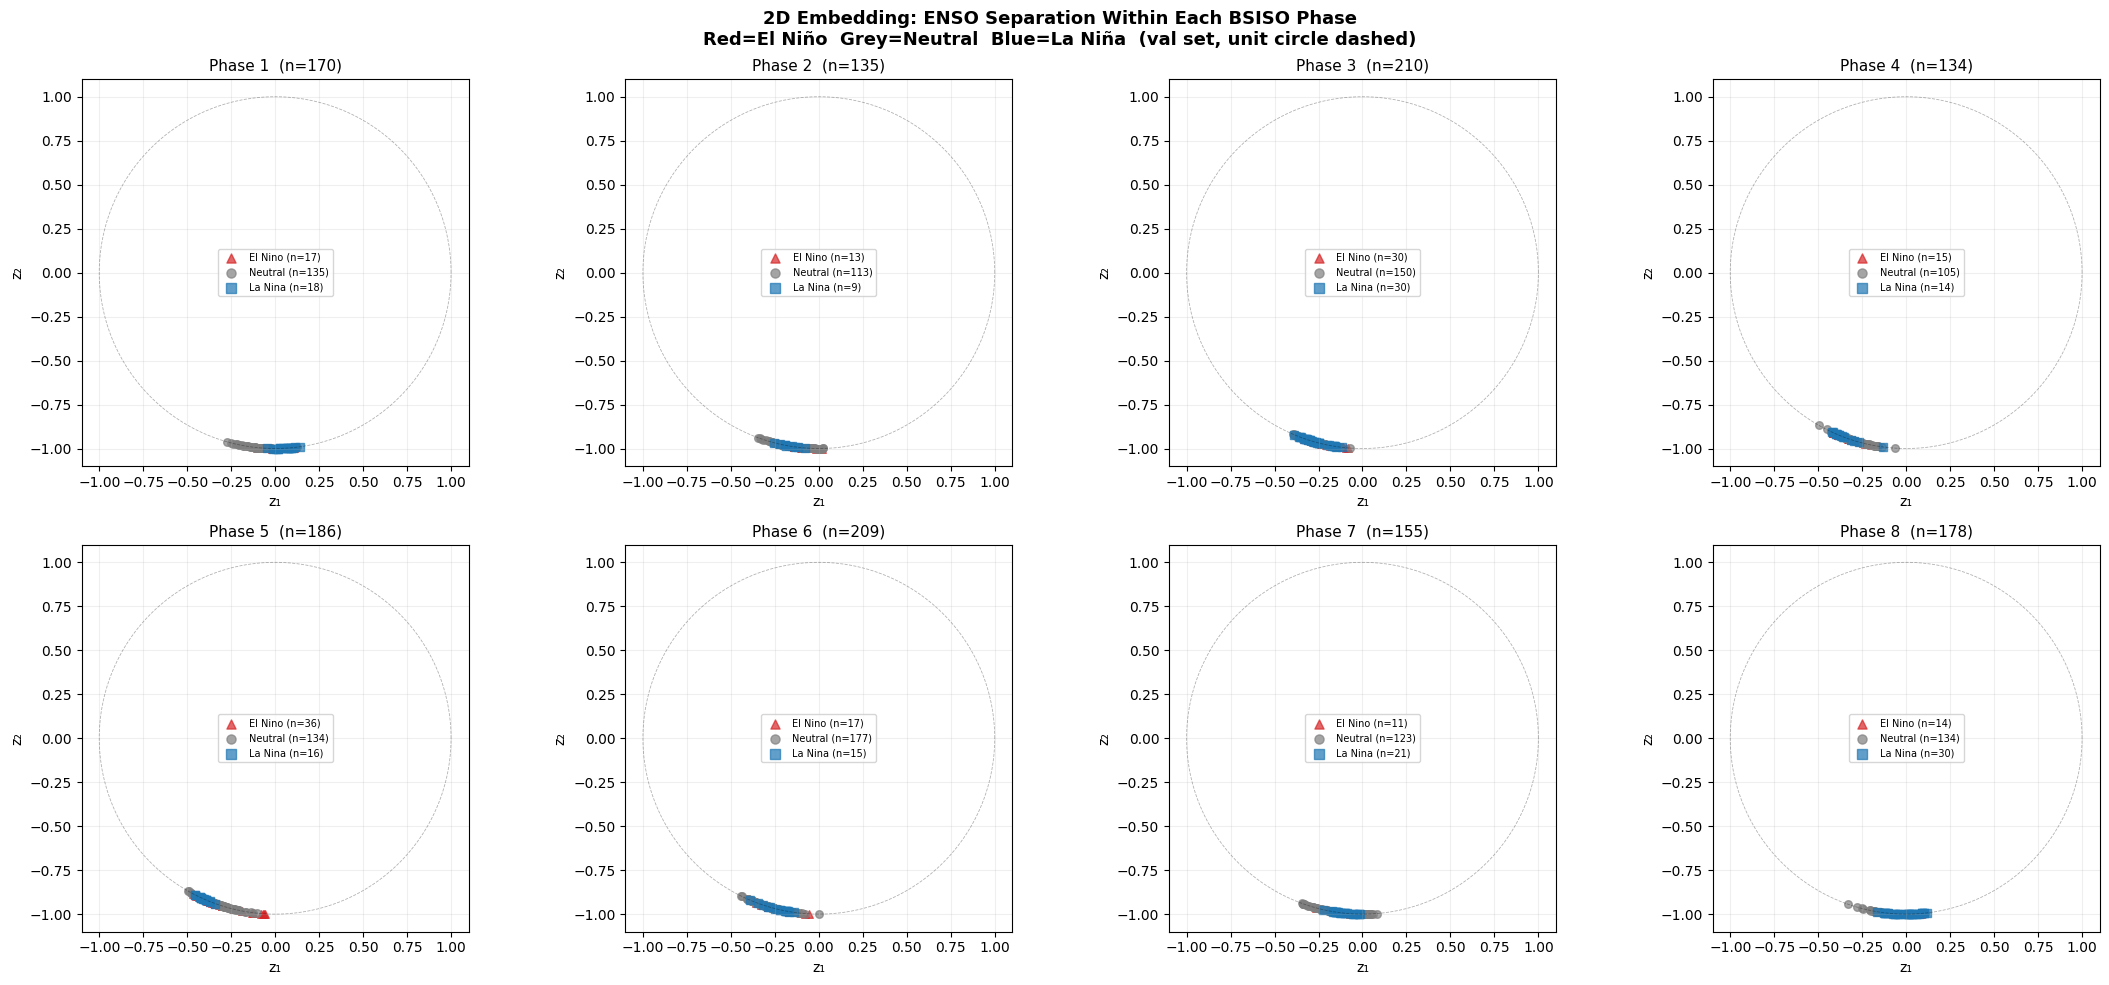

Saved: results/lee_2d/embedding_2d_by_phase.png


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('2D Embedding: ENSO Separation Within Each BSISO Phase\n'
             'Red=El Niño  Grey=Neutral  Blue=La Niña  (val set, unit circle dashed)',
             fontsize=13, fontweight='bold')

for phase in range(1, 9):
    ax   = axes[(phase - 1) // 4, (phase - 1) % 4]
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, linewidth=0.6)
    mask_phase = labels_val['bsiso_phase'] == phase
    for cat in ['El Nino', 'Neutral', 'La Nina']:
        mask = mask_phase & (labels_val['enso_category'] == cat)
        n = int(mask.sum())
        if n == 0:
            continue
        ax.scatter(Z_val_2d[mask, 0], Z_val_2d[mask, 1],
                   c=enso_palette[cat], marker=enso_marker[cat],
                   s=30, alpha=0.7, label=f'{cat} (n={n})')
    ax.set_title(f'Phase {phase}  (n={int(mask_phase.sum())})', fontsize=11)
    ax.legend(fontsize=7, markerscale=1.2)
    ax.set_aspect('equal'); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.grid(alpha=0.2)
    ax.set_xlabel('z₁'); ax.set_ylabel('z₂')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/embedding_2d_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/lee_2d/embedding_2d_by_phase.png')

## Cell 15 — Linear Probes

- **BSISO phase** — accuracy + 5-fold GroupKFold CV by year. Compare to 64D baseline 67.7% / 68.6 ± 1.0%.
- **ENSO category** — **balanced** accuracy (`class_weight='balanced'`, `scoring='balanced_accuracy'`). New evaluation that addresses the class-imbalance issue noted in `analysis_results_lee_mjjas.md` for the 64D run.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, GroupKFold

Z_train = embeddings_2d[train_idx]
Z_val   = embeddings_2d[val_idx]
year_groups = labels['date'].dt.year.values

probe_results = {}

print('=' * 65)
print('LINEAR PROBE RESULTS  (2D embedding, year-based split)')
print('64D Lee MJJAS baselines: phase 67.7% / 68.6 ± 1.0% CV')
print('=' * 65)

# --- Probe 1: BSISO Phase ---
y_train = labels.loc[train_idx, 'bsiso_phase'].values
y_val   = labels.loc[val_idx,   'bsiso_phase'].values

clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf.fit(Z_train, y_train)

train_acc = accuracy_score(y_train, clf.predict(Z_train))
val_acc   = accuracy_score(y_val,   clf.predict(Z_val))

gkf = GroupKFold(n_splits=5)
cv_scores = cross_val_score(clf, embeddings_2d, labels['bsiso_phase'].values,
                            cv=gkf, groups=year_groups,
                            scoring='accuracy', n_jobs=-1)

probe_results['BSISO Phase'] = {
    'train_acc': float(train_acc),
    'val_acc':   float(val_acc),
    'cv_mean':   float(cv_scores.mean()),
    'cv_std':    float(cv_scores.std()),
}

print(f'\nTask: BSISO Phase  (random = 12.5%, 64D baseline val = 67.7%)')
print(f'  Train accuracy:     {train_acc*100:.1f}%')
print(f'  Val   accuracy:     {val_acc*100:.1f}%   ← compare to 67.7% baseline')
print(f'  5-fold CV (year):   {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%   ← vs 68.6% ± 1.0%')
print(f'\n  Val classification report:')
print(classification_report(y_val, clf.predict(Z_val), zero_division=0))

# --- Probe 2: ENSO Category — BALANCED accuracy ---
y_train = labels.loc[train_idx, 'enso_category'].values
y_val   = labels.loc[val_idx,   'enso_category'].values

clf_bal = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
clf_bal.fit(Z_train, y_train)

train_bacc = balanced_accuracy_score(y_train, clf_bal.predict(Z_train))
val_bacc   = balanced_accuracy_score(y_val,   clf_bal.predict(Z_val))

cv_scores_b = cross_val_score(clf_bal, embeddings_2d, labels['enso_category'].values,
                              cv=gkf, groups=year_groups,
                              scoring='balanced_accuracy', n_jobs=-1)

probe_results['ENSO Category (balanced)'] = {
    'train_bal_acc': float(train_bacc),
    'val_bal_acc':   float(val_bacc),
    'cv_mean':       float(cv_scores_b.mean()),
    'cv_std':        float(cv_scores_b.std()),
}

print(f'\nTask: ENSO Category (balanced accuracy, 3 classes, random = 33.3%)')
print(f'  Train bal-acc:      {train_bacc*100:.1f}%')
print(f'  Val   bal-acc:      {val_bacc*100:.1f}%')
print(f'  5-fold CV (year):   {cv_scores_b.mean()*100:.1f}% ± {cv_scores_b.std()*100:.1f}%')
print(f'\n  Val classification report:')
print(classification_report(y_val, clf_bal.predict(Z_val), zero_division=0))

with open(f'{RESULTS_DIR}/linear_probe_results.json', 'w') as f:
    json.dump(probe_results, f, indent=2)
print(f'\nSaved: results/lee_2d/linear_probe_results.json')

LINEAR PROBE RESULTS  (2D embedding, year-based split)
64D Lee MJJAS baselines: phase 67.7% / 68.6 ± 1.0% CV

Task: BSISO Phase  (random = 12.5%, 64D baseline val = 67.7%)
  Train accuracy:     38.0%
  Val   accuracy:     32.8%   ← compare to 67.7% baseline
  5-fold CV (year):   36.1% ± 2.7%   ← vs 68.6% ± 1.0%

  Val classification report:
              precision    recall  f1-score   support

           1       0.29      0.12      0.17       170
           2       0.23      0.43      0.30       135
           3       0.31      0.67      0.42       210
           4       0.00      0.00      0.00       134
           5       0.38      0.69      0.49       186
           6       0.00      0.00      0.00       209
           7       0.00      0.00      0.00       155
           8       0.39      0.59      0.47       178

    accuracy                           0.33      1377
   macro avg       0.20      0.31      0.23      1377
weighted avg       0.21      0.33      0.24      1377


Task:

## Cell 16 — ENSO Displacement Z-Score (compare to 64D baseline 3.83)

Per-phase EN−LN centroid distance + 100-shuffle null. Same statistic as notebook 05, computed in the 2D space.

Phase     n(EN)  n(LN)  ||EN-LN||   cos(EN,LN)
----------------------------------------------
1           130    247     0.0043       1.0000
2           115    219     0.0072       1.0000
3           169    199     0.0072       1.0000
4           103    177     0.0048       1.0000
5           156    174     0.0132       0.9999
6           157    173     0.0253       0.9997
7           106    216     0.0028       1.0000
8           135    278     0.0141       0.9999

EN–LN displacement summary (2D):
  Observed mean: 0.0099
  Null baseline: 0.0070 ± 0.0019
  Z-score:       1.54   ← compare to 3.83 (64D baseline)


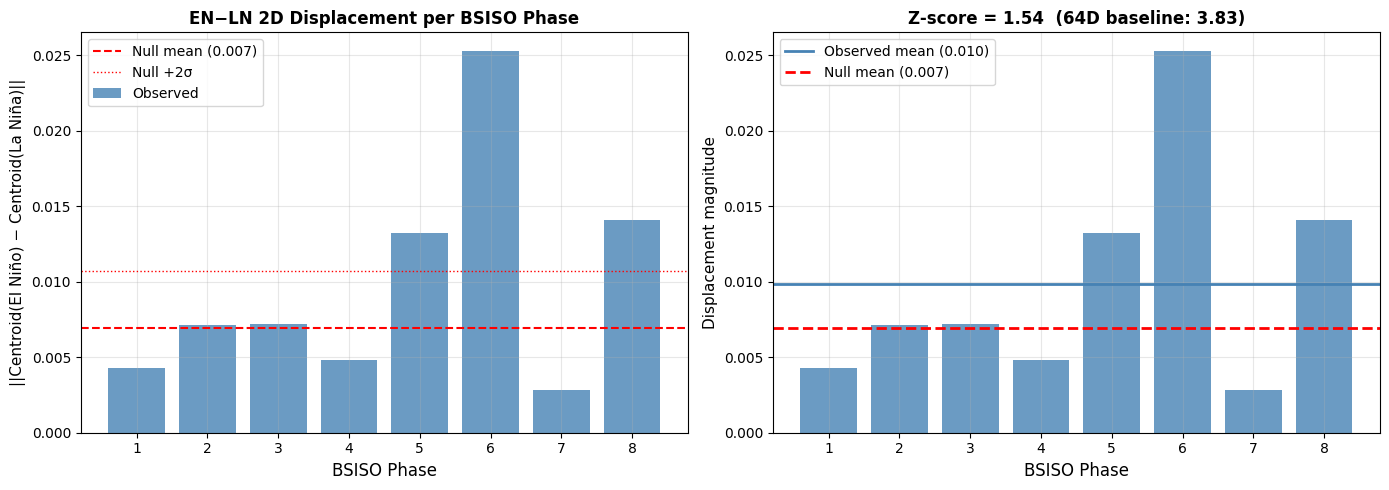

Saved: results/lee_2d/enso_displacement.png


In [16]:
phases      = range(1, 9)
disp_mag    = []
cos_EN_LN   = []

print(f'{"Phase":<8} {"n(EN)":>6} {"n(LN)":>6} {"||EN-LN||":>10} {"cos(EN,LN)":>12}')
print('-' * 46)

for phase in phases:
    mask_EN = (labels['bsiso_phase'] == phase) & (labels['enso_category'] == 'El Nino')
    mask_LN = (labels['bsiso_phase'] == phase) & (labels['enso_category'] == 'La Nina')

    if mask_EN.sum() < 3 or mask_LN.sum() < 3:
        disp_mag.append(np.nan); cos_EN_LN.append(np.nan)
        print(f'{phase:<8} {mask_EN.sum():>6} {mask_LN.sum():>6}  (too few samples)')
        continue

    c_EN = embeddings_2d[mask_EN].mean(axis=0)
    c_LN = embeddings_2d[mask_LN].mean(axis=0)

    mag = np.linalg.norm(c_EN - c_LN)
    cos = np.dot(c_EN, c_LN) / (np.linalg.norm(c_EN) * np.linalg.norm(c_LN) + 1e-8)

    disp_mag.append(mag)
    cos_EN_LN.append(cos)
    print(f'{phase:<8} {mask_EN.sum():>6} {mask_LN.sum():>6} {mag:>10.4f} {cos:>12.4f}')

# --- Random baseline (shuffle ENSO labels 100 times) ---
rng          = np.random.default_rng(42)
baseline_mag = []
for _ in range(100):
    shuffled = labels['enso_category'].sample(frac=1, random_state=rng.integers(1e6)).values
    mags_trial = []
    for phase in phases:
        mask_ph = (labels['bsiso_phase'] == phase).values
        mask_EN = mask_ph & (shuffled == 'El Nino')
        mask_LN = mask_ph & (shuffled == 'La Nina')
        if mask_EN.sum() < 3 or mask_LN.sum() < 3:
            continue
        c_EN = embeddings_2d[mask_EN].mean(axis=0)
        c_LN = embeddings_2d[mask_LN].mean(axis=0)
        mags_trial.append(np.linalg.norm(c_EN - c_LN))
    if mags_trial:
        baseline_mag.append(np.mean(mags_trial))

baseline_mean = float(np.mean(baseline_mag))
baseline_std  = float(np.std(baseline_mag))
observed_mean = float(np.nanmean(disp_mag))
z_score       = float((observed_mean - baseline_mean) / (baseline_std + 1e-8))

print(f'\nEN–LN displacement summary (2D):')
print(f'  Observed mean: {observed_mean:.4f}')
print(f'  Null baseline: {baseline_mean:.4f} ± {baseline_std:.4f}')
print(f'  Z-score:       {z_score:.2f}   ← compare to 3.83 (64D baseline)')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
valid_phases = [p for p, m in zip(phases, disp_mag) if not np.isnan(m)]
valid_mags   = [m for m in disp_mag if not np.isnan(m)]
ax.bar(valid_phases, valid_mags, color='steelblue', alpha=0.8, label='Observed')
ax.axhline(baseline_mean, color='red',    linestyle='--', linewidth=1.5, label=f'Null mean ({baseline_mean:.3f})')
ax.axhline(baseline_mean + 2*baseline_std, color='red', linestyle=':', linewidth=1, label='Null +2σ')
ax.set_xlabel('BSISO Phase', fontsize=12)
ax.set_ylabel('||Centroid(El Niño) − Centroid(La Niña)||', fontsize=11)
ax.set_title('EN−LN 2D Displacement per BSISO Phase', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 9))
ax.legend(fontsize=10); ax.grid(alpha=0.3)

ax = axes[1]
ax.bar(valid_phases, valid_mags, color='steelblue', alpha=0.8)
ax.axhline(observed_mean, color='steelblue', linestyle='-',  linewidth=2, label=f'Observed mean ({observed_mean:.3f})')
ax.axhline(baseline_mean, color='red',       linestyle='--', linewidth=2, label=f'Null mean ({baseline_mean:.3f})')
ax.set_title(f'Z-score = {z_score:.2f}  (64D baseline: 3.83)', fontsize=12, fontweight='bold')
ax.set_xlabel('BSISO Phase', fontsize=12)
ax.set_ylabel('Displacement magnitude', fontsize=11)
ax.set_xticks(range(1, 9))
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/enso_displacement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/lee_2d/enso_displacement.png')

## Cell 17 — Phase 1 Decision: 2D vs 64D Comparison Table

Final output. Writes `phase1_comparison.md` with the comparison table and the auto-generated decision (greenlight Phase 2 vs run Phase 4 dim-sweep first).

In [17]:
summary = {
    'Metric': ['BSISO Phase val acc', 'BSISO Phase 5-fold CV',
               'ENSO bal-acc val', 'ENSO bal-acc 5-fold CV',
               'ENSO displacement z-score'],
    '64D baseline (Lee MJJAS)': ['67.7%', '68.6% ± 1.0%',
                                  'n/a (used standard acc, 60.9%)',
                                  'n/a (used standard acc, 58.1% ± 0.0%)',
                                  '3.83'],
    '2D model': [
        f'{probe_results["BSISO Phase"]["val_acc"]*100:.1f}%',
        f'{probe_results["BSISO Phase"]["cv_mean"]*100:.1f}% ± {probe_results["BSISO Phase"]["cv_std"]*100:.1f}%',
        f'{probe_results["ENSO Category (balanced)"]["val_bal_acc"]*100:.1f}%',
        f'{probe_results["ENSO Category (balanced)"]["cv_mean"]*100:.1f}% ± {probe_results["ENSO Category (balanced)"]["cv_std"]*100:.1f}%',
        f'{z_score:.2f}',
    ],
}
df_summary = pd.DataFrame(summary)
print('=' * 78)
print('PHASE 1 COMPARISON — 2D vs 64D Baseline (Lee MJJAS, year-based split)')
print('=' * 78)
print(df_summary.to_string(index=False))

# Decision logic from extension_2d_plan.md
phase_pass = probe_results['BSISO Phase']['val_acc'] >= 0.62
z_pass     = z_score >= 3.0
decision_pass = phase_pass and z_pass

print(f'\nDecision criteria (extension_2d_plan.md):')
print(f'  BSISO phase val ≥ 62%  →  {"PASS" if phase_pass else "FAIL"} ({probe_results["BSISO Phase"]["val_acc"]*100:.1f}%)')
print(f'  ENSO z-score ≥ 3.0     →  {"PASS" if z_pass     else "FAIL"} ({z_score:.2f})')
print(f'  → {"GREENLIGHT Phase 2" if decision_pass else "RUN Phase 4 DIMENSION SWEEP first"}')

# Write report
report_path = f'{RESULTS_DIR}/phase1_comparison.md'
with open(report_path, 'w') as f:
    f.write(f'# Phase 1 — Supervised 2D vs 64D Baseline\n\n')
    f.write(f'**Auto-generated by notebook 07.**  \n')
    f.write(f'**Model:** `encoder_{RUN_TAG}_final.pth`, embedding_dim=2  \n')
    f.write(f'**Data:** Lee MJJAS, year-based split, N={len(X)}\n\n')
    f.write(df_summary.to_markdown(index=False))
    f.write(f'\n\n## Decision\n\n')
    if decision_pass:
        f.write(f'**BSISO is genuinely ≤2D in this representation.**\n\n')
        f.write(f'- 2D phase probe ({probe_results["BSISO Phase"]["val_acc"]*100:.1f}%) is within ~5pp of 64D (67.7%).\n')
        f.write(f'- 2D z-score ({z_score:.2f}) ≥ 3.0 threshold.\n\n')
        f.write(f'→ **Greenlight Phase 2** (SSL temporal 2D model).\n')
    else:
        f.write(f'**2D representation is insufficient.**\n\n')
        if not phase_pass:
            f.write(f'- 2D phase probe ({probe_results["BSISO Phase"]["val_acc"]*100:.1f}%) below 62% threshold.\n')
        if not z_pass:
            f.write(f'- 2D z-score ({z_score:.2f}) below 3.0 threshold.\n')
        f.write(f'\n→ **Run Phase 4 dimension sweep** {{1,2,4,8,16,32,64}} before Phase 2 to find the elbow.\n')
print(f'\nSaved: {report_path}')
print(f'\nAll Phase 1 outputs in {RESULTS_DIR}/:')
for f in sorted(os.listdir(RESULTS_DIR)):
    mb = os.path.getsize(f'{RESULTS_DIR}/{f}') / 1e6
    print(f'  {f}  ({mb:.2f} MB)')

PHASE 1 COMPARISON — 2D vs 64D Baseline (Lee MJJAS, year-based split)
                   Metric              64D baseline (Lee MJJAS)     2D model
      BSISO Phase val acc                                 67.7%        32.8%
    BSISO Phase 5-fold CV                          68.6% ± 1.0% 36.1% ± 2.7%
         ENSO bal-acc val        n/a (used standard acc, 60.9%)        35.4%
   ENSO bal-acc 5-fold CV n/a (used standard acc, 58.1% ± 0.0%) 35.2% ± 5.5%
ENSO displacement z-score                                  3.83         1.54

Decision criteria (extension_2d_plan.md):
  BSISO phase val ≥ 62%  →  FAIL (32.8%)
  ENSO z-score ≥ 3.0     →  FAIL (1.54)
  → RUN Phase 4 DIMENSION SWEEP first

Saved: /content/drive/MyDrive/BSISO_SSL_Project/results/lee_2d/phase1_comparison.md

All Phase 1 outputs in /content/drive/MyDrive/BSISO_SSL_Project/results/lee_2d/:
  embedding_2d_by_phase.png  (0.28 MB)
  embedding_2d_overview.png  (0.15 MB)
  embeddings.npy  (0.05 MB)
  enso_displacement.png  (0.08 MB

## Cell 18 — (Optional) Download All Phase 1 Outputs to Local Machine

In [18]:
from google.colab import files
for fname in sorted(os.listdir(RESULTS_DIR)):
    files.download(f'{RESULTS_DIR}/{fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Done!

If training + diagnostics completed, your Google Drive has:

```
BSISO_SSL_Project/
├── checkpoints/
│   ├── encoder_2d_lee_epoch_{10,20,30,40,50}.pth
│   ├── encoder_2d_lee_final.pth
│   └── training_history_2d_lee.json
└── results/lee_2d/
    ├── training_curves.png
    ├── embeddings.npy                  ← (6579, 2) all 2D embeddings
    ├── embedding_2d_overview.png       ← scatter colored by phase + ENSO
    ├── embedding_2d_by_phase.png       ← 8-panel within-phase ENSO scatter
    ├── linear_probe_results.json
    ├── enso_displacement.png
    └── phase1_comparison.md            ← decision: greenlight Phase 2 or dim-sweep
```

**Next step:**
- If `phase1_comparison.md` says "Greenlight Phase 2" → start `08_ssl_temporal_2d.ipynb`.
- If it says "Run Phase 4 dim sweep" → start the dim-sweep notebook to find intrinsic dimensionality before SSL.

Update the status checklist in `results/extension_2d_plan.md` either way.

---
*DDCS Project | jh9141@nyu.edu*